

### Detección de valores atípicos 

#### Actividad 1

* Entender el concepto de percentiles.
* Recordar el uso de _boxplots_. 
* Recordar el teorema de Chebyshov. 


#### Actividad 2

Tomar las variables `quantity` y  `gross_income`:

* Graficar histogramas.
* Visualmente responder: ¿Hay outliers?.
* Obtener el percentil 5 y el 95. ¿Qué valores son para cada variable? ¿Qué significan? 
* Obtener valores en promedio +/- 2 desviaciones para cada desviación.
* Responder para cada variable:
    * ¿Los valores obtenidos con el criterio de desviaciones y de percentiles son parecidos? ¿por qué?
    * ¿Necesitas eliminar outliers? Si sí, ¿qué método elegirías?

In [ ]:
df = pd.read_csv(r)

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


%matplotlib inline
plt.style.use('ggplot')


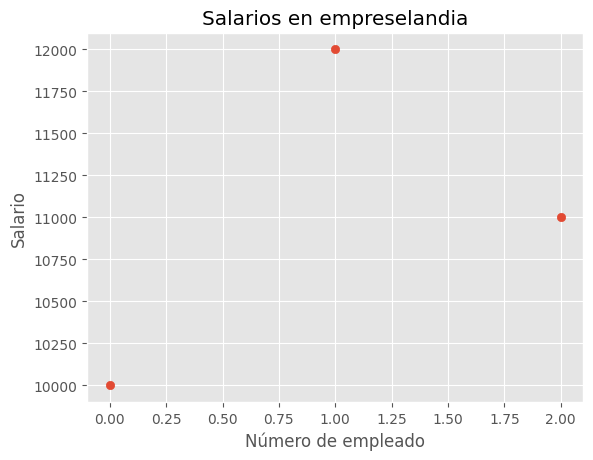

In [11]:
salarios = [10000, 12000, 11000]

plt.figure()
plt.scatter(range(len(salarios)), salarios)
plt.xlabel('Número de empleado')
plt.ylabel('Salario')
plt.title('Salarios en empreselandia')
plt.show()

In [10]:

promedio = np.mean(salarios)
std = np.round(np.std(salarios), 2)
print(f'El promedio del salario es de {promedio} pesos, la desviación es de {std} pesos')

El promedio del salario es de 13500.0 pesos, la desviación es de 4387.48 pesos


Recordemos definiciones básicas: 

**Promedio**:

$$
\mu = \frac{1}{n}\sum_{i=0}^n x_i
$$

**Desviación estándar**:

$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=0}^n (x_i - \mu)^2}
$$

Claramente podemos ver que un dato atípico puede alterar el promedio, si el promedio se altera se altera la desviación también. 

### Percentiles

Recordemos el concepto del percentil. 


El percentil es una medida de posición que se basa en previamente tener datos ordenados.


El `percentil 10 = 50` se lee como: _El 10% de los datos está **por debajo** de 50_

Apliquemos este concepto a datos de ventas de supermercado usados anteriormente. 

In [7]:
df = pd.read_csv('supermarket_sales.csv')

In [13]:
df.head(5)
df.columns = [c.lower().strip().replace(' ', '_').replace('%', '_percent') for c in df]

Normalicemos columnas antes de empezar. 

In [14]:
variable = 'total'

<Axes: >

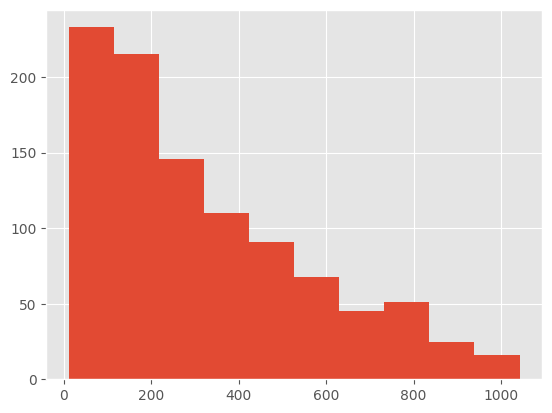

In [15]:
df[variable].hist()

Una forma sencilla de obtener percentiles es mediante `pandas` y su método `quantile`. 

In [17]:
percentiles = np.arange(0, 1.01, .01)

In [18]:
percentiles = df[variable].quantile(q=percentiles)
percentiles

0.00      10.678500
0.01      19.188435
0.02      26.230260
0.03      31.736250
0.04      34.601280
           ...     
0.96     836.573220
0.97     874.340460
0.98     931.061040
0.99     950.265750
1.00    1042.650000
Name: total, Length: 101, dtype: float64

Grafiquemos estos datos vs el histograma anterior. 

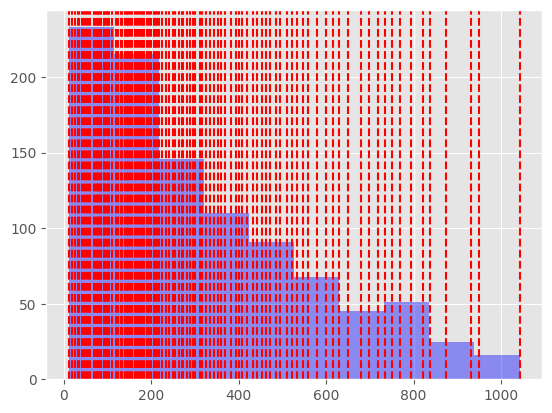

In [19]:
fix, ax = plt.subplots()
df[variable].hist(ax=ax, color='blue', alpha=0.4)

for value in percentiles:
    ax.axvline(value, color='red', linestyle='--')


Comprobemos la cantidad de información que hay por debajo de cada dato. 

#### ¿De qué sirve obtener percentiles? 

Usarás percentiles cuando: 

* Quieras obtener datos sobre tu distribución. 
* Quieres obtener un dato "típico", es decir, algo que representa a cierto porcentaje de la población. 


#### ¿Cómo usar esto para detección de atípicos? 

En realidad no hay una regla para detección de datos atípicos con el uso de percentiles. Los percentiles nos pueden hablar de un dato "típico". Pueden determinarse:

* Un porcentaje de datos a "tirar". 
* Comparar la media/mediana (percentil 50) de la distribución.* 
* Observar un percentil "típico" (como el 75 o el 80) y comparar con el máximo.*


Los puntos con un "*" tienen relación con los siguientes temas.

### Box plots

Los diagramas de caja y bigote son la representación gráfica de los cuantiles (percentiles 25, 50 y 75) de una determina serie de datos. 


Se compone de la siguiente manera: 

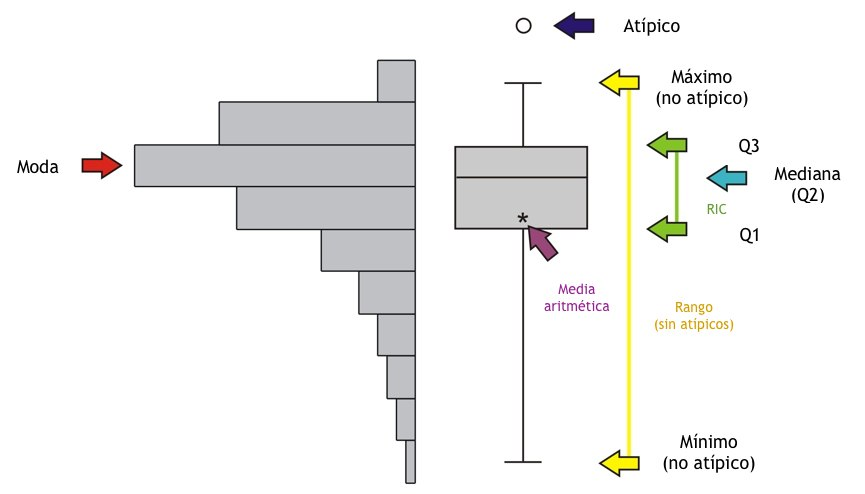

Es una manera visual de entender nuestros datos pues nos dan una idea del valor en el cual se ubica cierto porcentaje de los datos así como una sugerencia de _outliers_. 


Los _bigotes_ son el valor máximo/mínimo no atípicos o bien el _rango intercuartílico_ multiplicado por 1.5. 

Los valores fuera de $1.5 \times \text{RIC}$ son considerados como atípicos. 

$\text{RIC} = Q_3 - Q_1$

$\text{Lower limit} = Q_1 - 1.5 \times \text{RIC}$

$\text{Upper limit} = Q_3 + 1.5 \times \text{RIC}$

<Axes: >

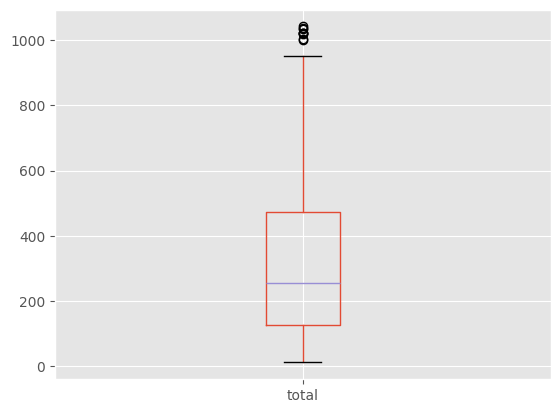

In [20]:
df.boxplot(column=variable)

Calculemos los datos del diagrama. 

In [21]:
# El mínimo
min_ = df[variable].min()

# Cuantiles
q1, q2, q3 = df[variable].quantile(q=[0.25, 0.5., 0.75])

# El máximo 
max_ = df[variable].max()

# RIC

lower_limit = q1 - 1.5 * (q3 - q1)
upper_limit = q3 + 1.5 * (q3 - q1)

lower_limit, upper_limit

SyntaxError: invalid syntax (525890452.py, line 5)

In [3]:

# Mín y máx


# Cuantiles


# RIC



### Desigualdad de Chebyshov
La desigualdad de Chebyshev nos habla de que la probabilidad de que una variable aleatoria difiera de su media en al menos $c$ desviaciones estándar es menor o igual que $\frac{1}{c^2}, c>1$.

Generemos un loop para ver qué tantos valores deberían de quedar dentro de límites puestos por la desviación estándar ($\sigma$).

Veamos cuántos en realidad están dentro de un límite de desviaciones en un ejemplo sencillo: 

In [4]:
# Grafiquemos un histograma de nuestros datos 




# Pongamos como límite las desviaciones estándar


Vemos que la _realidad supera a la ficción_, por lo que un buen límite empírico para calificar a un _outlier_ como tal serán de 2 a 3 desviaciones estándar.

Es importante cuidar los datos atípicos, sobre todo considerando el tipo de modelo que utilizaremos. 